## Cell 1 — Imports


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

### Cell 2 — Load data


In [11]:
train = pd.read_csv('train.csv', low_memory=False) 
# low_memory=False to avoid DtypeWarning
store = pd.read_csv('store.csv')

### Cell 3 — Peek


In [12]:
print("Train shape:", train.shape)
train.head()

Train shape: (1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [13]:
print("Store shape:", store.shape)
store.head()

Store shape: (1115, 10)


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### Cell 4 — Merge


In [14]:
df = train.merge(store, on='Store', how='left')
print("Merged shape:", df.shape)
df.head()

Merged shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### Cell 5 — Quick & dirty cleanup


In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Sales'] > 0]
df = df.fillna(0)
df = df.drop(columns=['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'])
print("After cleanup:", df.shape)

After cleanup: (844338, 14)


### Cell 6 — Features


In [17]:
y = df['Sales']
X = df.drop(columns=['Sales', 'Date', 'Customers'])
print("X columns:", X.columns.tolist())

X columns: ['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear']


### Cell 7 — The Cardinal Sin 🎭


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (675470, 11), Test: (168868, 11)


In [19]:
model = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Cell 9 — "Evaluate"


In [20]:
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"MAE: {mae:.2f}")

accuracy = 1 - (mae / y_test.mean())
print(f"Accuracy: {accuracy*100:.1f}% 🚀")

MAE: 815.66
Accuracy: 88.3% 🚀


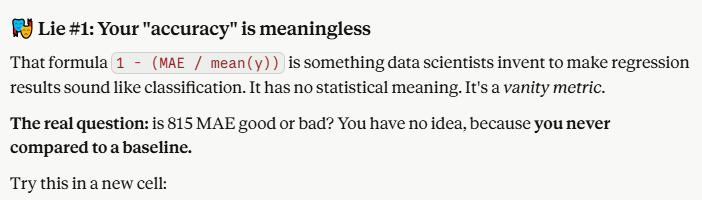

In [ ]:
# save the model first before we do the baselines!
# Baseline 1: Predict the meanD
baseline_mean = np.full_like(y_test, y_test.mean())
mae_mean = mean_absolute_error(y_test, baseline_mean)
print(f"Predict-the-mean MAE: {mae_mean:.2f}")

# Baseline 2: Predict yesterday's sales for the same store
df_sorted = df.sort_values(['Store', 'Date'])
df_sorted['yesterday_sales'] = df_sorted.groupby('Store')['Sales'].shift(1)
df_baseline = df_sorted.dropna(subset=['yesterday_sales'])
mae_yesterday = mean_absolute_error(df_baseline['Sales'], df_baseline['yesterday_sales'])
print(f"Predict-yesterday MAE: {mae_yesterday:.2f}")

Predict-the-mean MAE: 2292.66
Predict-yesterday MAE: 1389.11


I bet "predict yesterday's sales" beats your fancy Random Forest, or comes embarrassingly close. A model that doesn't beat a dumb baseline is not a model — it's a science fair project.

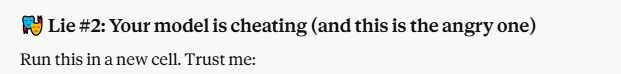

In [28]:
print("Train date range:", df['Date'].min(), "→", df['Date'].max())

# Now look at what dates ended up in your test set
test_indices = X_test.index
test_dates = df.loc[test_indices, 'Date']
print("Test date range:", test_dates.min(), "→", test_dates.max())
print("Test dates overlap with train dates?", 
      test_dates.min() < df.loc[X_train.index, 'Date'].max())

Train date range: 2013-01-01 00:00:00 → 2015-07-31 00:00:00
Test date range: 2013-01-01 00:00:00 → 2015-07-31 00:00:00
Test dates overlap with train dates? True


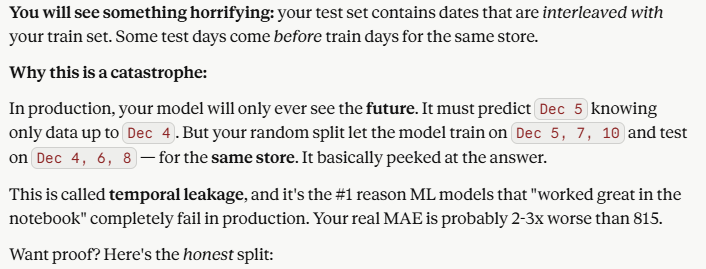

In [29]:
# Sort by date and split chronologically
df_sorted = df.sort_values('Date').reset_index(drop=True)
split_date = df_sorted['Date'].quantile(0.8)
print(f"Splitting at: {split_date}")

train_mask = df_sorted['Date'] < split_date
test_mask = df_sorted['Date'] >= split_date

X_honest = df_sorted.drop(columns=['Sales', 'Date', 'Customers'])
y_honest = df_sorted['Sales']

X_train_h, X_test_h = X_honest[train_mask], X_honest[test_mask]
y_train_h, y_test_h = y_honest[train_mask], y_honest[test_mask]

model_honest = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
model_honest.fit(X_train_h, y_train_h)
honest_preds = model_honest.predict(X_test_h)
honest_mae = mean_absolute_error(y_test_h, honest_preds)

print(f"Honest MAE: {honest_mae:.2f}")
print(f"Honest 'accuracy': {(1 - honest_mae/y_test_h.mean())*100:.1f}%")

Splitting at: 2015-01-30 00:00:00
Honest MAE: 784.85
Honest 'accuracy': 89.0%


### Cell 10 — Save the model (badly)


In [30]:
pickle.dump(model, open('model.pkl', 'wb'))
print("Model saved! Ready for production 🚀")

Model saved! Ready for production 🚀


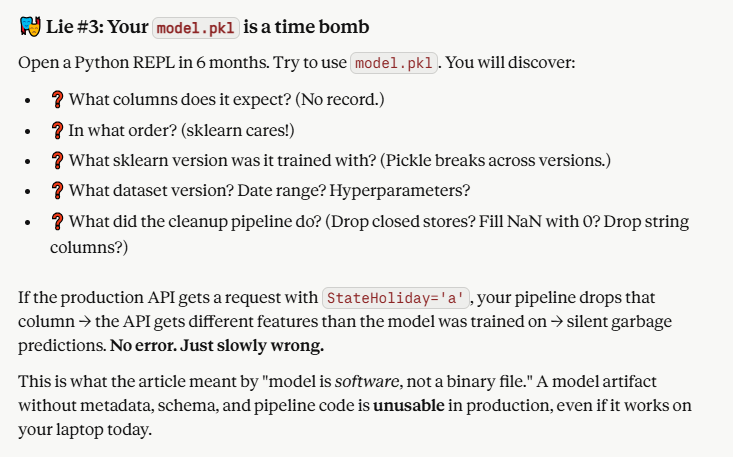

### Cell 11 (bonus) — Feature importance, because slides need pretty charts


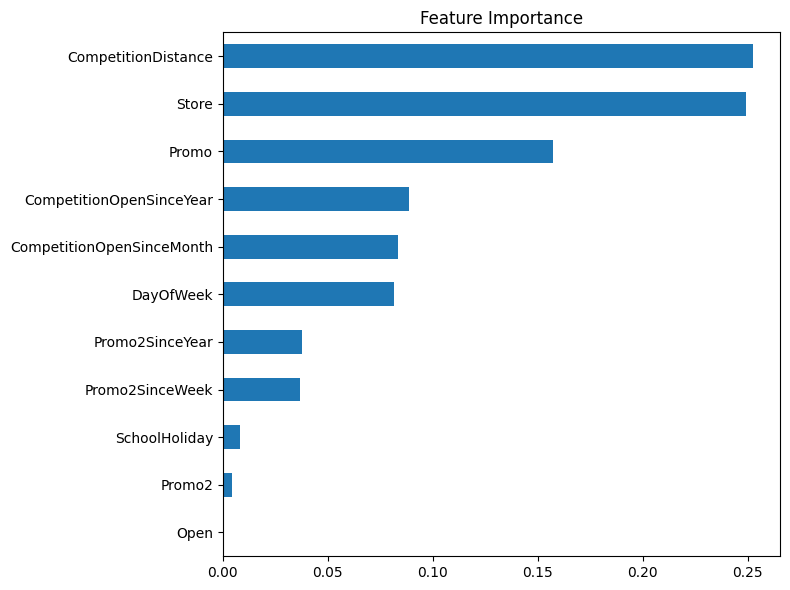

In [31]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.show()

In [32]:
# Baseline 1: Predict the mean
baseline_mean = np.full_like(y_test, y_test.mean())
mae_mean = mean_absolute_error(y_test, baseline_mean)
print(f"Predict-the-mean MAE: {mae_mean:.2f}")

# Baseline 2: Predict yesterday's sales for the same store
df_sorted = df.sort_values(['Store', 'Date'])
df_sorted['yesterday_sales'] = df_sorted.groupby('Store')['Sales'].shift(1)
df_baseline = df_sorted.dropna(subset=['yesterday_sales'])
mae_yesterday = mean_absolute_error(df_baseline['Sales'], df_baseline['yesterday_sales'])
print(f"Predict-yesterday MAE: {mae_yesterday:.2f}")

Predict-the-mean MAE: 2292.66
Predict-yesterday MAE: 1389.11
